<a href="https://colab.research.google.com/github/Sravani-AIML/Handwritten_digits_prediction/blob/main/cnn_rnn_minst_digit_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

train_set = MNIST(root = "./data", train = True, download= True, transform = transform)
test_set = MNIST(root ="./data", train = False, download = True, transform = transform)


100%|██████████| 9.91M/9.91M [00:00<00:00, 36.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 898kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.10MB/s]


In [3]:
train_set

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

###sample image

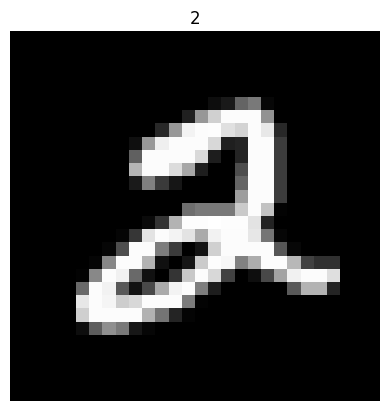

In [12]:

img, label = train_set[5]

#image - tensor- [1, 28,28]
#image.squeeze() - [28,28] or reshape(28,28)
plt.imshow(img.reshape(28,28), cmap = "gray")
plt.title(label)
plt.axis("off")
plt.show()

In [3]:
trainloader = DataLoader(train_set, batch_size = 64, shuffle = True )
testloader = DataLoader(test_set, batch_size = 64, shuffle = True)

##CNN

In [47]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    #Convolutional Layers
    self.convo_layers = nn.Sequential(
        nn.Conv2d(1,32, kernel_size = 3, padding =1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2, stride = 2),

        nn.Conv2d(32, 64, kernel_size = 3, padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2, stride = 2)

    )
    #fully connected layers
    self.fc_layers = nn.Sequential(
        nn.Linear(7*7*64, 256),
        nn.ReLU(),
        nn.Linear(256, 10)
    )
  def forward(self, x):
    x = self.convo_layers(x)
    x = x.view(x.size(0), -1)
    x = self.fc_layers(x)
    return x


In [48]:
model = CNN()

In [49]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [50]:
#Training

epochs = 10
for epoch in range(epochs):
  running_loss = 0.0
  model.train()
  for images, labels in trainloader:
    #set gradients to zero
    optimizer.zero_grad()
    outputs = model.forward(images)
    loss = criterion(outputs, labels)
    #apply backward function
    loss.backward()
    #Update weights
    optimizer.step()
    running_loss += loss.item()
  print(f"epoch {epoch+1}/{epochs} and loss {running_loss/len(trainloader)}")


epoch 1/10 and loss 0.1363128911684464
epoch 2/10 and loss 0.04293978781906514
epoch 3/10 and loss 0.028321871783559906
epoch 4/10 and loss 0.02160928531108101
epoch 5/10 and loss 0.015686866070124733
epoch 6/10 and loss 0.012735977046683587
epoch 7/10 and loss 0.009519937164389827
epoch 8/10 and loss 0.009384966718460182
epoch 9/10 and loss 0.005728430589388183
epoch 10/10 and loss 0.007582361128641908


In [51]:
correct_labels = 0
total_values = 0
predictions_cnn = []
true_labels_cnn = []
model.eval()
with torch.no_grad():
  for images, labels in testloader:
    outputs = model.forward(images)
    _, predicted = torch.max(outputs, 1)
    correct_labels += (predicted == labels).sum().item()
    total_values += labels.size(0)
    predictions_cnn.extend(predicted)
    true_labels_cnn.extend(labels)
  print(f"Accuracy: {correct_labels/total_values*100}")
  print(f"Confusion Matrix: \n{confusion_matrix(predictions_cnn, true_labels_cnn)}",)



Accuracy: 99.11999999999999
Confusion Matrix: 
[[ 978    0    1    2    0    3    8    0    2    0]
 [   0 1135    0    0    0    0    1    5    1    1]
 [   0    0 1027    1    0    0    0    3    1    1]
 [   0    0    0  998    0    2    0    1    0    0]
 [   0    0    1    0  976    0    3    0    0    6]
 [   0    0    0    7    0  885    5    0    1    7]
 [   0    0    0    0    1    1  941    0    0    0]
 [   0    0    3    1    0    0    0 1015    0    3]
 [   1    0    0    1    1    1    0    1  967    1]
 [   1    0    0    0    4    0    0    3    2  990]]


##RNN

In [18]:
class RNN(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers):
    super().__init__()

    #Number of hidden dimensions
    self.hidden_size = hidden_size
    #Number of hidden layers
    self.num_layers = num_layers

    #RNN
    self.rnn = nn.RNN(input_size, hidden_size, num_layers,
                      batch_first = True, nonlinearity = 'relu' )
    #Fully connected layer or Readout layer
    output_dim = 10 #Output dimension- no.of classes(10 digits)
    self.fc = nn.Linear(hidden_size, output_dim)

  def forward(self, x):

    #Initialize hidden state with zeros
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

    #one time step
    out, hn = self.rnn(x, h0)
    out = self.fc(out[:,-1,:])
    return out


In [24]:
#rnn
input_size = 28  #input dimension(image size)
hidden_size = 150 #hidden state dimension
num_layers= 1 # Number of hidden layers

model_rnn = RNN(input_size, hidden_size, num_layers)


In [25]:
#Cross entropy loss
error = nn.CrossEntropyLoss()

optimizer = optim.Adam(model_rnn.parameters())



In [26]:
epochs = 10

for epoch in range(epochs):
  model_rnn.train()
  running_loss = 0.0
  for images, labels in trainloader:
    #clear gradients
    optimizer.zero_grad()
    #squeeze train dimenstion ->[batch, sequence_dim, input_dim]
    images = images.squeeze(1)
    #forward propagation
    outputs = model_rnn.forward(images)
    #Calculate cross entropy loss
    loss = error(outputs, labels)
    #Calculating gradients
    loss.backward()

    #Update parameters
    optimizer.step()

    #update loss
    running_loss += loss.item()

  print(f"epoch {epoch +1}/{epochs} and loss {running_loss/len(trainloader)}")






epoch 1/10 and loss 0.713990791678937
epoch 2/10 and loss 0.2794105553709622
epoch 3/10 and loss 0.209727742796593
epoch 4/10 and loss 0.1752892893784717
epoch 5/10 and loss 0.16004137520485723
epoch 6/10 and loss 0.142001567688435
epoch 7/10 and loss 0.12287952385466498
epoch 8/10 and loss 0.11639878551300957
epoch 9/10 and loss 0.11054922992250384
epoch 10/10 and loss 0.10697103090269534


In [28]:
from sklearn.metrics import confusion_matrix

In [31]:
total_values = 0
correct_labels = 0
predictions = []
true_labels = []
model_rnn.eval()
with torch.no_grad():
  for images, labels in testloader:
    #change dimension from [batch,1,28,28] -> [batch, 28,28]
    images = images.squeeze(1)
    outputs = model_rnn.forward(images)
    _, predicted = torch.max(outputs, 1)
    correct_labels += (predicted == labels).sum().item()
    predictions.extend(predicted)
    true_labels.extend(labels)
    total_values += labels.size(0)

  print(f"Accuracy: {correct_labels/total_values * 100}")
  print(f"confusion matrix: \n {confusion_matrix(predictions, true_labels)}")



Accuracy: 96.87
confusion matrix: 
 [[ 958    0    0    0    0    4    6    0    0    2]
 [   0 1119    0    0    1    1    2    2    1    0]
 [   1    4 1000   10    1    0    6   12    2    0]
 [   0    6    4  968    1    8    1    1    2    1]
 [   3    0    2    0  945    0    1    0    1   20]
 [   0    0    0   18    0  861    2    1    7   13]
 [  15    0    2    0    7    6  934    0    3    1]
 [   1    2    9    4    1    1    0  988    3    2]
 [   1    3   15    0    5    4    6    8  950    6]
 [   1    1    0   10   21    7    0   16    5  964]]


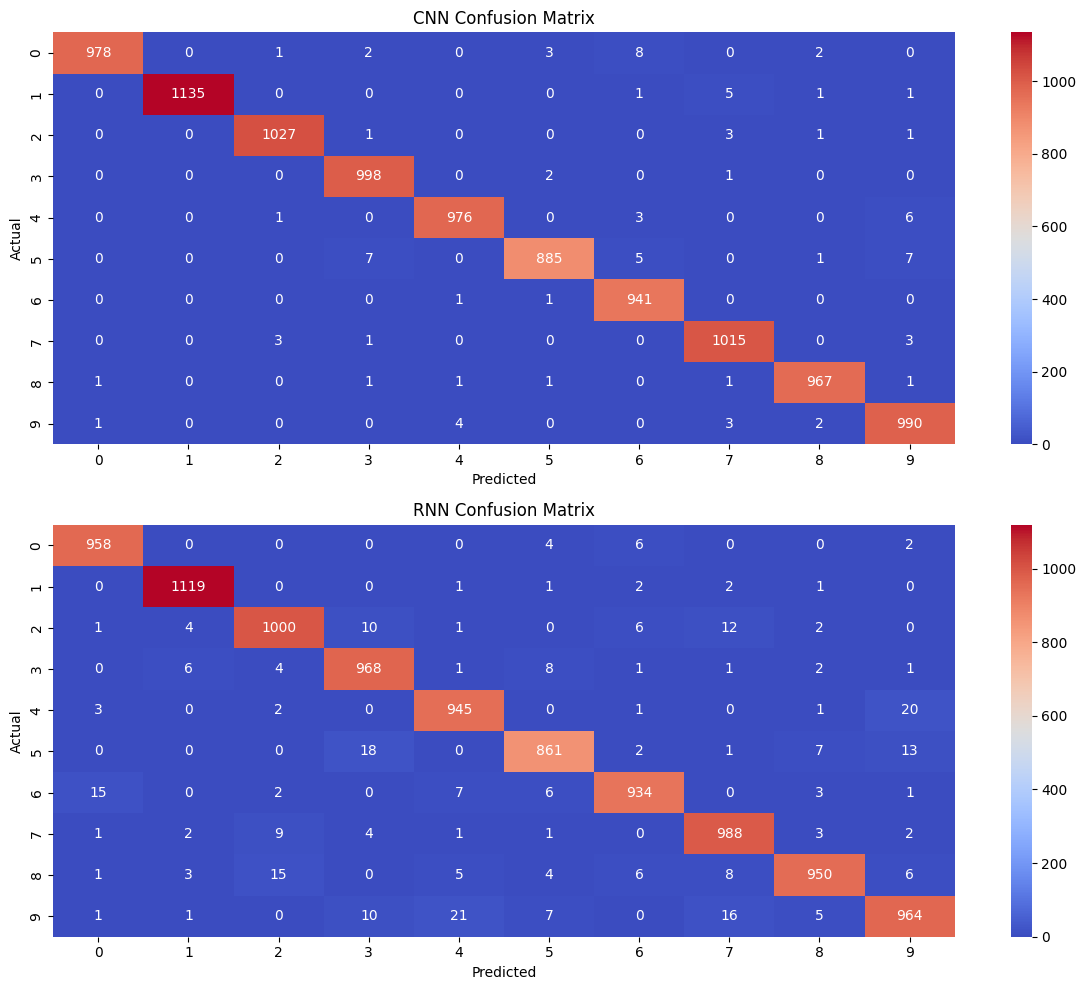

In [56]:
fig, axes = plt.subplots(2,1, figsize= (12,10))

data_rnn = confusion_matrix(predictions, true_labels)
data_cnn = confusion_matrix(predictions_cnn, true_labels_cnn)
sns.heatmap(data_cnn, annot = True, fmt = "d", cmap = "coolwarm",
            xticklabels = range(10), yticklabels = range(10),
            ax = axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("CNN Confusion Matrix")

sns.heatmap(data_rnn, annot = True, fmt = "d", cmap = "coolwarm",
            xticklabels = range(10), yticklabels = range(10),
            ax = axes[1])

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("RNN Confusion Matrix")

plt.tight_layout()
plt.show()
